# Clustering d'offres d'emploi par fouille de données textuelles

**Maxime Bronny — 19009314**  
Master 1 Informatique, Big Data — Université Paris 8  
UE Fouille de données textuelles

---

## Problématique

Comment regrouper automatiquement des offres d'emploi en catégories pertinentes à partir de leur contenu textuel, en utilisant des techniques de clustering non supervisé et de représentation vectorielle des textes ?

## Démarche

Ce notebook met en œuvre un pipeline complet de fouille de données textuelles :

1. **Chargement et échantillonnage** du corpus d'offres d'emploi
2. **Exploration statistique** du corpus
3. **Prétraitement textuel** (nettoyage HTML, boilerplate, stopwords, lemmatisation)
4. **Vectorisation TF-IDF** des textes nettoyés
5. **Clustering K-Means** avec sélection du nombre de clusters
6. **Comparaison avec DBSCAN** comme méthode alternative
7. **Analyse et interprétation** des clusters obtenus

---
## 1. Chargement des données

Le dataset utilisé est un corpus d'offres d'emploi LinkedIn contenant environ 124 000 annonces en anglais. Chaque annonce comprend un **titre** (`title`) et une **description** textuelle complète (`description`).

Un échantillon aléatoire de 30 000 offres (graine fixe pour la reproductibilité) est extrait du corpus pour le clustering, ce qui offre un bon compromis entre couverture statistique et temps de calcul. Le chargement est optimisé en ne lisant que les colonnes nécessaires. Le pipeline complet s'exécute en environ 5 minutes sur machine personnelle.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import clean_text, build_corpus_text

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
N_OFFRES = 30_000

In [2]:
# Chargement des colonnes utiles uniquement (optimisation mémoire)
COLS = ['job_id', 'title', 'description', 'company_name',
        'formatted_experience_level', 'formatted_work_type', 'location']

df_full = pd.read_csv('../Données/postings.csv', usecols=COLS)
print(f"Dataset complet : {len(df_full):,} offres")

Dataset complet : 123,849 offres


In [3]:
# Suppression des lignes sans description
df = df_full.dropna(subset=["description"])

# Filtrage des descriptions trop courtes (< 100 caractères)
mask_short = df["description"].str.len() < 100
print(f"Descriptions < 100 caractères supprimées : {mask_short.sum()}")
df = df[~mask_short].reset_index(drop=True)
print(f"Après filtrage : {len(df):,} offres exploitables")

# Échantillonnage aléatoire reproductible
df = df.sample(n=N_OFFRES, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Échantillon retenu : {len(df):,} offres")

del df_full

Descriptions < 100 caractères supprimées : 142
Après filtrage : 123,700 offres exploitables
Échantillon retenu : 30,000 offres


---
## 2. Exploration du corpus

Avant tout traitement, nous examinons la structure et la qualité des données pour identifier d'éventuels problèmes.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   job_id                      30000 non-null  int64
 1   company_name                29636 non-null  str  
 2   title                       30000 non-null  str  
 3   description                 30000 non-null  str  
 4   location                    30000 non-null  str  
 5   formatted_work_type         30000 non-null  str  
 6   formatted_experience_level  22911 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.6 MB


In [5]:
df[['title', 'company_name', 'formatted_experience_level']].head(10)

,title,company_name,formatted_experience_level
0,Professional Pharmaceutical Sales Representative,Syneos Health Commercial Solutions,Mid-Senior level
1,"Environmental Technician (Onsite Role in Ames,...",Hach,Entry level
2,Mixed Commercial Construction Superintendent,Russell Tobin,Mid-Senior level
3,EVS Tech,Coshocton Regional Medical Center,Entry level
4,Sales Development Representative,Vaco,Entry level
5,Front End Entry Level,Safeway,NaN
6,AN-Assistant Manager-A00027,Rent-A-Center,Mid-Senior level
7,Sr. Network Engineer,ValueMomentum,Mid-Senior level
8,Warehouse Supervisor,ABB,NaN
9,Water Resources- H&H Project Engineer,"Johnson, Mirmiran & Thompson",Entry level


In [6]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df[COLS].isnull().sum())
print(f"\nTaux de remplissage du niveau d'expérience : "
      f"{df['formatted_experience_level'].notna().mean():.1%}")

Valeurs manquantes :
job_id                           0
title                            0
description                      0
company_name                   364
formatted_experience_level    7089
formatted_work_type              0
location                         0
dtype: int64

Taux de remplissage du niveau d'expérience : 76.4%


In [7]:
# Statistiques sur les champs textuels
df['desc_length'] = df['description'].str.len()
df['title_length'] = df['title'].str.len()

print("=== Longueur des descriptions (caractères) ===")
print(df['desc_length'].describe().round(0))
print(f"\n=== Longueur des titres (caractères) ===")
print(df['title_length'].describe().round(0))

=== Longueur des descriptions (caractères) ===
count    30000.0
mean      3770.0
std       2134.0
min        107.0
25%       2187.0
50%       3446.0
75%       4990.0
max      19515.0
Name: desc_length, dtype: float64

=== Longueur des titres (caractères) ===
count    30000.0
mean        32.0
std         16.0
min          2.0
25%         20.0
50%         28.0
75%         39.0
max        199.0
Name: title_length, dtype: float64


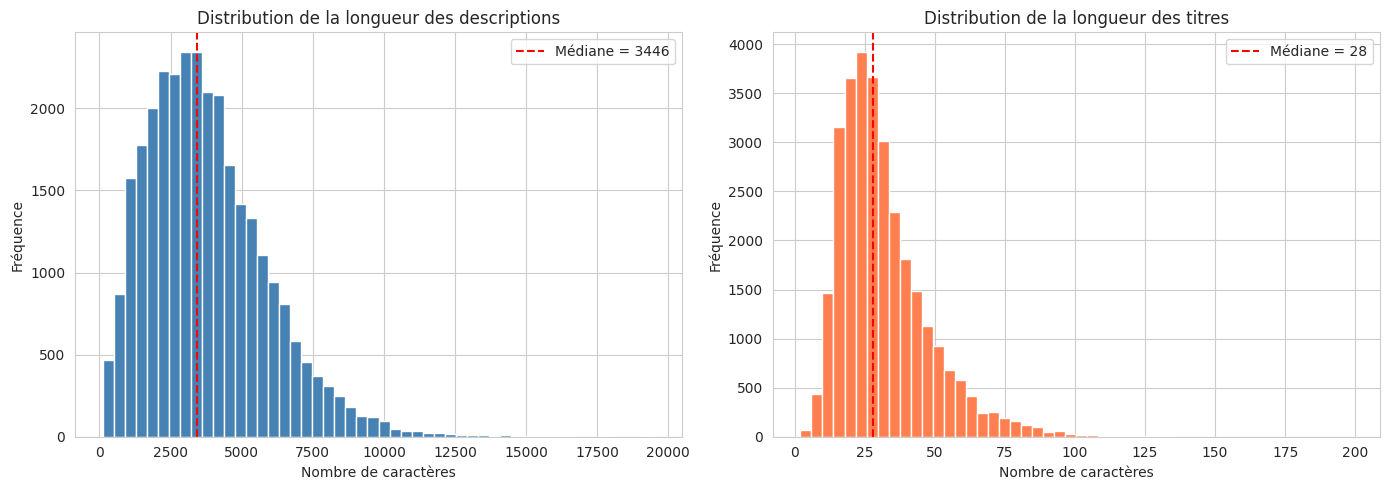

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['desc_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de la longueur des descriptions')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['desc_length'].median(), color='red', linestyle='--',
                label=f"Médiane = {df['desc_length'].median():.0f}")
axes[0].legend()

axes[1].hist(df['title_length'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution de la longueur des titres')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(df['title_length'].median(), color='red', linestyle='--',
                label=f"Médiane = {df['title_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
if df['formatted_experience_level'].notna().sum() > 0:
    print("Répartition des niveaux d'expérience :")
    print(df['formatted_experience_level'].value_counts())

Répartition des niveaux d'expérience :
formatted_experience_level
Mid-Senior level    10083
Entry level          8919
Associate            2345
Director              919
Internship            363
Executive             282
Name: count, dtype: int64


### Bilan de l'exploration

- Les champs `title` et `description` sont toujours remplis et de longueur suffisante.
- Les descriptions sont riches (médiane ~3 400 caractères), ce qui est favorable au clustering textuel.
- Le champ `skills_desc` a été exclu car il est vide dans ~90% des cas.
- Le niveau d'expérience (`formatted_experience_level`) est renseigné pour environ 76% des offres ; il servira pour l'analyse croisée post-clustering.

---
## 3. Prétraitement textuel

Le prétraitement est une étape critique dont dépend fortement la qualité du clustering. Le pipeline appliqué comprend :

1. **Concaténation** du titre (doublé pour renforcer son poids sémantique) et de la description
2. **Suppression du HTML** résiduel et des entités HTML
3. **Suppression du boilerplate légal/RH** : les mentions de type *equal opportunity employer*, *affirmative action*, *regardless of race*, etc. sont présentes dans ~30% des descriptions. Ces blocs de texte sont identiques d'une annonce à l'autre et ne sont pas discriminants pour le clustering par métier. Leur conservation créait un cluster parasite regroupant les annonces par leur texte juridique plutôt que par leur contenu métier.
4. **Mise en minuscules**
5. **Suppression des caractères non alphabétiques**
6. **Suppression des stopwords** anglais (NLTK)
7. **Lemmatisation** (WordNetLemmatizer)
8. **Filtrage** des tokens de moins de 3 caractères

In [10]:
# Construction du champ texte combiné (titre doublé + description)
df['text'] = df.apply(build_corpus_text, axis=1)

print("Exemple de texte brut (500 premiers caractères) :")
print(df['text'].iloc[0][:500])

Exemple de texte brut (500 premiers caractères) :
Professional Pharmaceutical Sales Representative Professional Pharmaceutical Sales Representative Description

You have what it takes: a competitive drive coupled with exceptional sales ability.

In this role, you will be an integral part of a nationwide sales team developing and managing an assigned territory. You'll partner with a leading pharmaceutical company one of Syneos Health's long-term clients and most robust relationships. You will:

Proactively demonstrate and promote clients product


In [11]:
print("Nettoyage en cours (peut prendre ~1 min sur 10 000 documents)...")
df['text_clean'] = df['text'].apply(clean_text)
print("Nettoyage terminé.")

# Suppression des textes vides après nettoyage
empty_mask = df['text_clean'].str.strip().eq('')
print(f"Textes vides après nettoyage : {empty_mask.sum()}")
if empty_mask.sum() > 0:
    df = df[~empty_mask].reset_index(drop=True)
print(f"Corpus final : {len(df)} documents")

Nettoyage en cours (peut prendre ~1 min sur 10 000 documents)...


Nettoyage terminé.
Textes vides après nettoyage : 0
Corpus final : 30000 documents


In [12]:
# Comparaison avant / après nettoyage
idx = 0
print("=== AVANT nettoyage ===")
print(df['text'].iloc[idx][:400])
print(f"\n=== APRÈS nettoyage ===")
print(df['text_clean'].iloc[idx][:400])

=== AVANT nettoyage ===
Professional Pharmaceutical Sales Representative Professional Pharmaceutical Sales Representative Description

You have what it takes: a competitive drive coupled with exceptional sales ability.

In this role, you will be an integral part of a nationwide sales team developing and managing an assigned territory. You'll partner with a leading pharmaceutical company one of Syneos Health's long-term c

=== APRÈS nettoyage ===
professional pharmaceutical sale representative professional pharmaceutical sale representative description take competitive drive coupled exceptional sale ability role integral part nationwide sale team developing managing assigned territory partner leading pharmaceutical company one syneos health long term client robust relationship proactively demonstrate promote client product targeted non tar


Nombre de tokens par document après nettoyage :
count    30000.0
mean       322.0
std        177.0
min          8.0
25%        192.0
50%        299.0
75%        421.0
max       1737.0
Name: n_tokens, dtype: float64


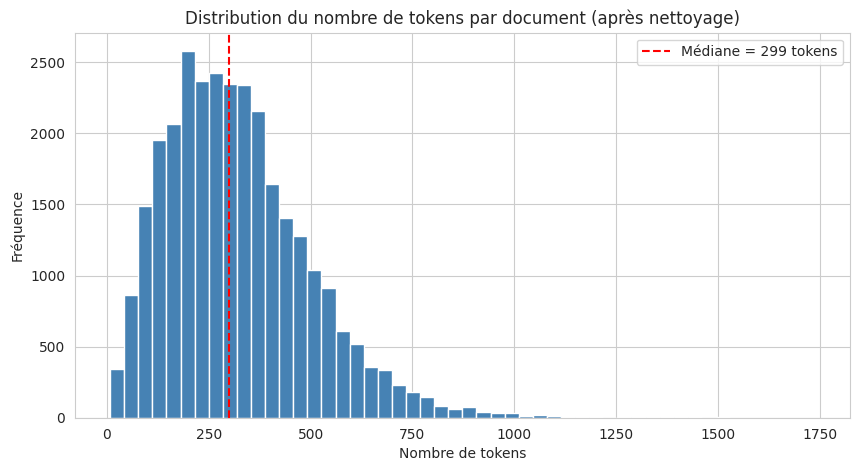

In [13]:
df['n_tokens'] = df['text_clean'].str.split().str.len()

print("Nombre de tokens par document après nettoyage :")
print(df['n_tokens'].describe().round(0))

plt.figure(figsize=(10, 5))
plt.hist(df['n_tokens'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(df['n_tokens'].median(), color='red', linestyle='--',
            label=f"Médiane = {df['n_tokens'].median():.0f} tokens")
plt.title('Distribution du nombre de tokens par document (après nettoyage)')
plt.xlabel('Nombre de tokens')
plt.ylabel('Fréquence')
plt.legend()
plt.savefig('../outputs/distribution_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

### Bilan du prétraitement

Le nettoyage produit des documents dont la longueur médiane se situe autour de 300 tokens, ce qui est suffisant pour une représentation TF-IDF discriminante. La suppression du boilerplate légal/RH est essentielle pour éviter que le clustering ne regroupe les annonces par leur texte juridique commun plutôt que par leur contenu métier.

---
## 4. Vectorisation TF-IDF

Les textes nettoyés sont transformés en vecteurs TF-IDF. Les paramètres ont été choisis pour obtenir une représentation discriminante tout en limitant le bruit :

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `max_features` | 10 000 | Vocabulaire élargi pour exploiter la richesse du corpus complet |
| `max_df` | 0.85 | Exclusion des termes trop fréquents (présents dans >85% des documents) |
| `min_df` | 50 | Exclusion des termes apparaissant dans moins de 50 documents, adapté à la taille du corpus |
| `sublinear_tf` | True | Atténuation logarithmique (1 + log(tf)) pour éviter la domination des termes très fréquents dans un document |
| `ngram_range` | (1, 2) | Inclusion des bigrammes pour capturer des expressions composées (ex : *machine learning*, *data analyst*) |

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    max_df=0.85,
    min_df=50,
    sublinear_tf=True,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['text_clean'])
print(f"Matrice TF-IDF : {X.shape[0]} documents × {X.shape[1]} termes")
print(f"Sparsité : {(1 - X.nnz / (X.shape[0] * X.shape[1])):.2%}")

Matrice TF-IDF : 30000 documents × 10000 termes
Sparsité : 97.48%


In [15]:
feature_names = tfidf.get_feature_names_out()
print(f"Taille du vocabulaire : {len(feature_names)}")

# Exemples de bigrammes capturés
bigrams = [f for f in feature_names if ' ' in f]
print(f"Nombre de bigrammes : {len(bigrams)}")
print(f"Exemples de bigrammes : {bigrams[:20]}")

Taille du vocabulaire : 10000
Nombre de bigrammes : 5374
Exemples de bigrammes : ['ability ability', 'ability adapt', 'ability adjust', 'ability analyze', 'ability apply', 'ability build', 'ability collaborate', 'ability communicate', 'ability create', 'ability deliver', 'ability demonstrate', 'ability develop', 'ability drive', 'ability effectively', 'ability establish', 'ability follow', 'ability handle', 'ability identify', 'ability influence', 'ability interact']


---
## 5. Clustering K-Means

### 5.1 Recherche du nombre optimal de clusters

Le nombre de clusters *k* est un hyperparamètre qu'il faut choisir. Deux méthodes complémentaires sont utilisées :

- **Méthode du coude (inertie)** : on trace l'inertie (somme des distances intra-cluster) en fonction de *k* et on cherche le point d'inflexion.
- **Score silhouette** : il mesure à quel point chaque document est bien assigné à son cluster par rapport aux clusters voisins. Un score proche de 1 indique une bonne séparation, un score proche de 0 indique des chevauchements.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 16)
inertias = []
silhouette_scores = []

print("Recherche du nombre optimal de clusters...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=10000, random_state=RANDOM_SEED)
    silhouette_scores.append(sil)
    print(f"  k={k:2d} | Inertie={km.inertia_:,.0f} | Silhouette={sil:.4f}")

print("Terminé.")

Recherche du nombre optimal de clusters...


  k= 2 | Inertie=27,945 | Silhouette=0.0085


  k= 3 | Inertie=27,768 | Silhouette=0.0091


  k= 4 | Inertie=27,654 | Silhouette=0.0093


  k= 5 | Inertie=27,561 | Silhouette=0.0090


...

  k=11 | Inertie=27,078 | Silhouette=0.0133


  k=12 | Inertie=26,997 | Silhouette=0.0133


  k=13 | Inertie=26,977 | Silhouette=0.0148


  k=14 | Inertie=26,866 | Silhouette=0.0142


  k=15 | Inertie=26,867 | Silhouette=0.0142
Terminé.


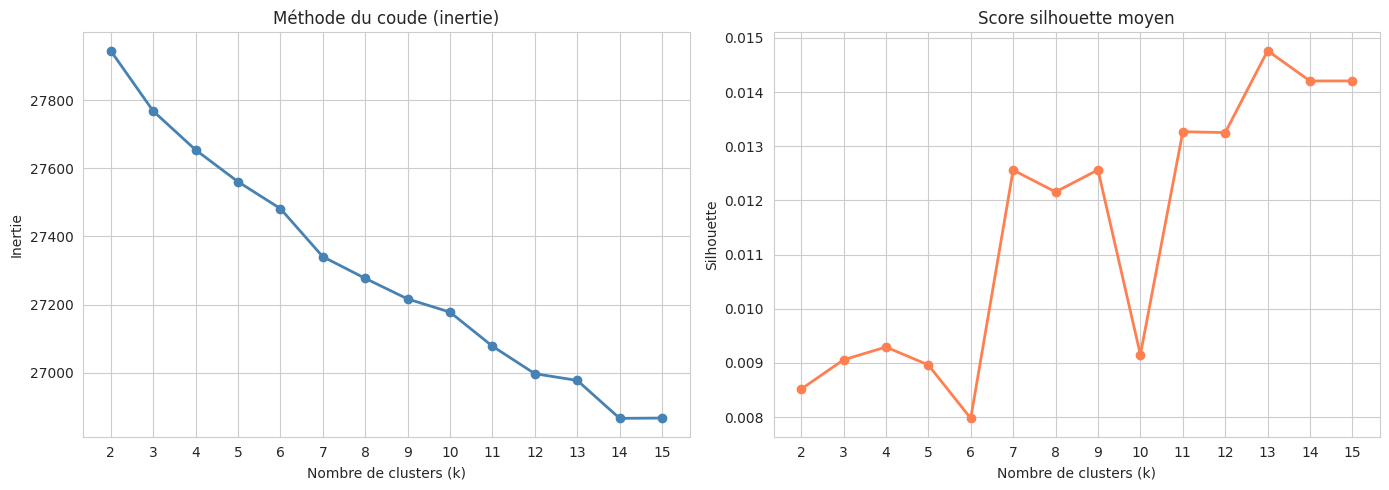

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].set_title('Méthode du coude (inertie)')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouette_scores, 'o-', color='coral', linewidth=2, markersize=6)
axes[1].set_title('Score silhouette moyen')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Choix du nombre de clusters

Les scores silhouette restent globalement faibles (typiquement < 0.05), ce qui est **attendu et courant** en clustering de textes avec TF-IDF. Cela s'explique par :
- la **haute dimensionnalité** de l'espace TF-IDF (10 000 dimensions), où la notion de distance euclidienne est moins pertinente ;
- la **nature continue** du langage : une offre de *data analyst* partage du vocabulaire avec les offres *IT* et les offres *finance*, créant des chevauchements naturels.

Le choix de *k* ne peut donc pas reposer uniquement sur le score silhouette. Nous croisons :
1. La **courbe du coude** (recherche du ralentissement de la décroissance de l'inertie)
2. Le **score silhouette** (maximum relatif)
3. L'**interprétabilité qualitative** des clusters (les groupes obtenus ont-ils un sens métier ?)

Après analyse, **k=8** est retenu comme compromis entre granularité et interprétabilité. Un *k* trop élevé (ex : 14) fragmente les groupes en sous-catégories difficilement distinguables, tandis qu'un *k* trop bas (ex : 3-4) fusionne des métiers très différents.

In [18]:
CHOSEN_K = 8

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_SEED, n_init=10, max_iter=300)
df['cluster'] = kmeans_final.fit_predict(X)

sil_final = silhouette_score(X, df['cluster'])
print(f"K-Means avec k={CHOSEN_K}")
print(f"Score silhouette : {sil_final:.4f}")
print(f"Inertie : {kmeans_final.inertia_:,.0f}")
print(f"\nRépartition des clusters :")
print(df['cluster'].value_counts().sort_index())

K-Means avec k=8
Score silhouette : 0.0121
Inertie : 27,277

Répartition des clusters :
cluster
0     703
1    4288
2    2238
3    7579
4    3760
5    3974
6     150
7    7308
Name: count, dtype: int64


### 5.3 Comparaison avec DBSCAN

DBSCAN est un algorithme de clustering basé sur la densité. Contrairement à K-Means, il ne nécessite pas de spécifier le nombre de clusters à l'avance et peut identifier des clusters de forme arbitraire. Il détecte aussi les points de bruit (*outliers*).

Cependant, DBSCAN est **sensible au choix de ses paramètres** (`eps`, `min_samples`), et fonctionne mal en haute dimension car les distances deviennent uniformes. Nous le testons ici sur les données réduites par TruncatedSVD pour évaluer son apport.

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD

# Réduction de dimension avant DBSCAN (nécessaire en haute dimension)
svd_50 = TruncatedSVD(n_components=50, random_state=RANDOM_SEED)
X_reduced = svd_50.fit_transform(X)
print(f"Variance expliquée par 50 composantes : {svd_50.explained_variance_ratio_.sum():.2%}")

# Test de DBSCAN avec plusieurs valeurs de eps
for eps in [0.5, 1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = db.fit_predict(X_reduced)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    print(f"  eps={eps:.1f} → {n_clusters} clusters, {n_noise} points de bruit ({n_noise/len(db_labels):.1%})")

Variance expliquée par 50 composantes : 13.80%


  eps=0.5 → 3 clusters, 0 points de bruit (0.0%)


  eps=1.0 → 1 clusters, 0 points de bruit (0.0%)


  eps=1.5 → 1 clusters, 0 points de bruit (0.0%)


  eps=2.0 → 1 clusters, 0 points de bruit (0.0%)


### Bilan de la comparaison

DBSCAN produit soit un unique cluster massif avec peu de bruit (eps élevé), soit une majorité de points classés comme bruit (eps faible). Ce comportement est caractéristique des données textuelles où les distances entre documents sont relativement uniformes en haute dimension (*curse of dimensionality*).

**K-Means est retenu comme méthode principale** car il produit des groupes interprétables et permet un contrôle direct de la granularité via le choix de *k*. DBSCAN reste adapté pour des données à densité variable, ce qui n'est pas le cas des données textuelles TF-IDF.

---
## 6. Analyse et interprétation des clusters

### 6.1 Taille des clusters

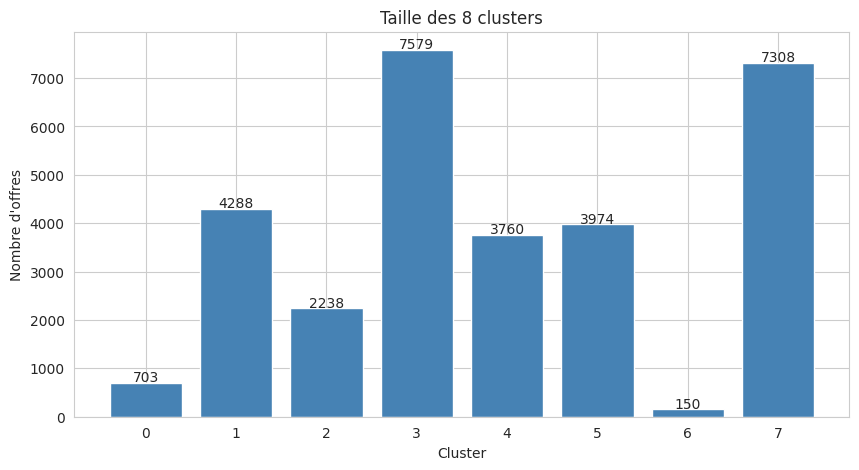

Écart-type des tailles : 2731
Ratio max/min : 50.5x


In [20]:
cluster_sizes = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values,
               color='steelblue', edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontsize=10)
plt.title(f'Taille des {CHOSEN_K} clusters')
plt.xlabel('Cluster')
plt.ylabel("Nombre d'offres")
plt.xticks(range(CHOSEN_K))
plt.savefig('../outputs/taille_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Écart-type des tailles : {cluster_sizes.std():.0f}")
print(f"Ratio max/min : {cluster_sizes.max() / cluster_sizes.min():.1f}x")

### 6.2 Termes les plus représentatifs par cluster

Pour chaque cluster, les 10 termes ayant le poids le plus élevé dans le centroïde sont extraits. Ces termes permettent d'identifier le thème dominant de chaque groupe.

In [21]:
def get_top_terms(tfidf_model, kmeans_model, n_terms=10):
    """Extrait les termes les plus importants par cluster via les centroïdes."""
    terms = tfidf_model.get_feature_names_out()
    centroids = kmeans_model.cluster_centers_
    result = {}
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n_terms:][::-1]
        result[i] = [terms[j] for j in top_indices]
    return result

top_terms = get_top_terms(tfidf, kmeans_final)

for cid, terms in top_terms.items():
    size = cluster_sizes[cid]
    print(f"\nCluster {cid} ({size} offres)")
    print(f"  Termes : {', '.join(terms)}")


Cluster 0 (703 offres)
  Termes : occasionally, physical demand, duty job, performing duty, described representative, job employee, employee, function job, demand, hand

Cluster 1 (4288 offres)
  Termes : equipment, safety, work, maintenance, required, technician, job, must, duty, ability

Cluster 2 (2238 offres)
  Termes : store, sale, customer, retail, associate, merchandise, store manager, customer service, product, sale associate

Cluster 3 (7579 offres)
  Termes : work, service, client, team, benefit, company, opportunity, time, job, customer

Cluster 4 (3760 offres)
  Termes : patient, care, nurse, nursing, health, healthcare, registered, registered nurse, patient care, clinical

Cluster 5 (3974 offres)
  Termes : engineer, design, engineering, software, system, technical, data, developer, technology, development

Cluster 6 (150 offres)
  Termes : galt, earnings, business owner, sale manager, figure, credit, executive consultant, production earnings, state trade, earnings expect

### 6.3 Exemples d'offres les plus proches du centroïde

Pour chaque cluster, les 3 offres les plus proches du centroïde sont sélectionnées. Ces exemples sont plus représentatifs du cluster que des lignes choisies au hasard.

In [22]:
from sklearn.metrics import pairwise_distances

for cid in range(CHOSEN_K):
    mask = df['cluster'] == cid
    indices = df.index[mask]

    # Distance de chaque document au centroïde
    centroid = kmeans_final.cluster_centers_[cid].reshape(1, -1)
    dists = pairwise_distances(X[indices], centroid, metric='euclidean').flatten()
    closest = indices[np.argsort(dists)[:3]]

    print(f"\n--- Cluster {cid} — Offres les plus représentatives ---")
    for idx in closest:
        row = df.loc[idx]
        company = row['company_name'] if pd.notna(row['company_name']) else 'N/A'
        print(f"  • {row['title']}")
        print(f"    Entreprise : {company}")
        # Extrait nettoyé du début de la description
        desc_preview = row['description'][:150].replace('\n', ' ')
        print(f"    Extrait : {desc_preview}...")
        print()


--- Cluster 0 — Offres les plus représentatives ---
  • store driver
    Entreprise : Advance Auto Parts
    Extrait : Job Description  What is a Store Driver?  Entry level store position capable of supporting delivery of parts to commercial customers. The role has the...

  • store driver
    Entreprise : Advance Auto Parts
    Extrait : Job Description  What is a Store Driver?  Entry level store position capable of supporting delivery of parts to commercial customers. The role has the...

  • Store Driver
    Entreprise : Advance Auto Parts
    Extrait : Job Description  What is a Store Driver?  Entry level store position capable of supporting delivery of parts to commercial customers. The role has the...


--- Cluster 1 — Offres les plus représentatives ---
  • Healthcare Facilities Technician
    Entreprise : Oregon Health & Science University
    Extrait : Department Overview  OHSU is proud to be designated a Magnet hospital by the American Nurses Credentialing Center. Just 9 per

### 6.4 Résumé interprétatif des clusters

À partir des termes dominants et des exemples représentatifs, nous proposons une synthèse pour chaque cluster. Les étiquettes sont des interprétations humaines, non des labels automatiques.

In [23]:
print(f"{'Cluster':<10} {'Taille':<10} {'Termes dominants (top 5)'}")
print("-" * 80)
for cid in range(CHOSEN_K):
    terms_str = ', '.join(top_terms[cid][:5])
    print(f"{cid:<10} {cluster_sizes[cid]:<10} {terms_str}")

print("\n" + "=" * 80)
print("L'étiquetage interprétatif de chaque cluster est proposé dans")
print("le rapport, sur la base des termes ci-dessus et des exemples.")
print("Certains clusters peuvent rester flous ou mélanger plusieurs thématiques.")

Cluster    Taille     Termes dominants (top 5)
--------------------------------------------------------------------------------
0          703        occasionally, physical demand, duty job, performing duty, described representative
1          4288       equipment, safety, work, maintenance, required
2          2238       store, sale, customer, retail, associate
3          7579       work, service, client, team, benefit
4          3760       patient, care, nurse, nursing, health
5          3974       engineer, design, engineering, software, system
6          150        galt, earnings, business owner, sale manager, figure
7          7308       business, management, project, team, manager

L'étiquetage interprétatif de chaque cluster est proposé dans
le rapport, sur la base des termes ci-dessus et des exemples.
Certains clusters peuvent rester flous ou mélanger plusieurs thématiques.


### 6.5 Visualisation 2D (TruncatedSVD)

La matrice TF-IDF est projetée en 2 dimensions par TruncatedSVD pour permettre une visualisation.

**Attention** : la réduction de 10 000 dimensions à 2 entraîne une perte d'information très importante. La variance expliquée par 2 composantes est généralement inférieure à 5%. Cette visualisation donne une intuition de la structure globale mais ne doit pas être surinterprétée.

Variance expliquée par 2 composantes : 1.58%


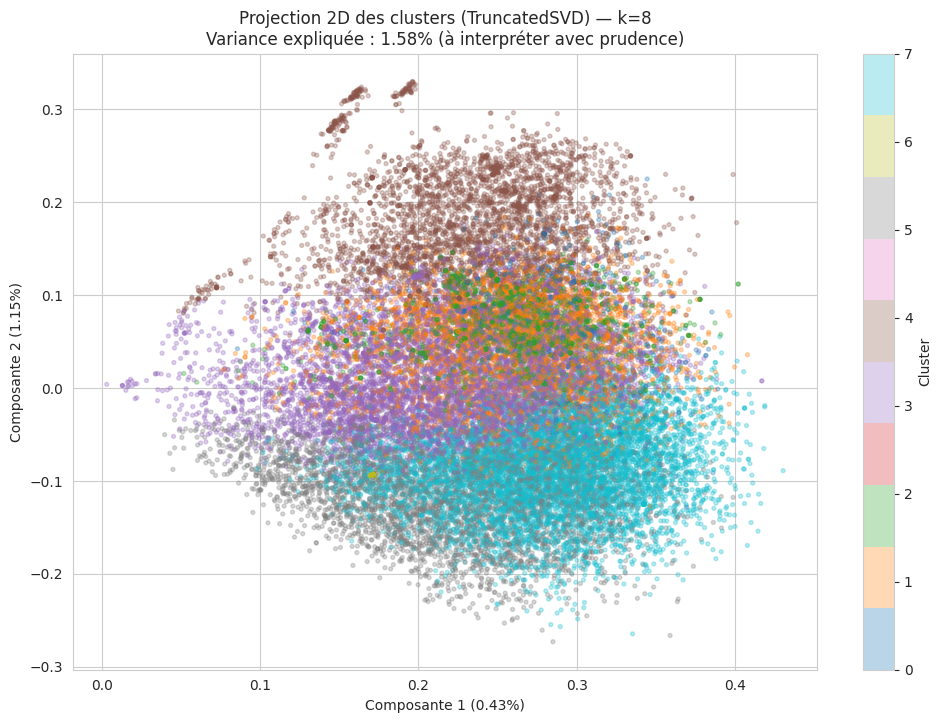

In [24]:
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
X_2d = svd_2d.fit_transform(X)

variance_explained = svd_2d.explained_variance_ratio_.sum()
print(f"Variance expliquée par 2 composantes : {variance_explained:.2%}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'],
                      cmap='tab10', alpha=0.3, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Projection 2D des clusters (TruncatedSVD) — k={CHOSEN_K}\n'
          f'Variance expliquée : {variance_explained:.2%} '
          f'(à interpréter avec prudence)')
plt.xlabel(f'Composante 1 ({svd_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Composante 2 ({svd_2d.explained_variance_ratio_[1]:.2%})')
plt.savefig('../outputs/clusters_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Évaluation

#### Score silhouette global et par cluster

In [25]:
from sklearn.metrics import silhouette_samples

print(f"Score silhouette global (k={CHOSEN_K}) : {sil_final:.4f}")
print()

sil_per_sample = silhouette_samples(X, df['cluster'])
print(f"{'Cluster':<10} {'Taille':<10} {'Silhouette moy.':<20} {'% scores > 0'}")
print("-" * 60)
for cid in range(CHOSEN_K):
    mask = df['cluster'] == cid
    sil_cluster = sil_per_sample[mask]
    pct_pos = (sil_cluster > 0).mean() * 100
    print(f"{cid:<10} {mask.sum():<10} {sil_cluster.mean():<20.4f} {pct_pos:.0f}%")

Score silhouette global (k=8) : 0.0121



Cluster    Taille     Silhouette moy.      % scores > 0
------------------------------------------------------------
0          703        0.0597               100%
1          4288       -0.0016              49%
2          2238       0.0217               98%
3          7579       -0.0068              5%
4          3760       0.0240               99%
5          3974       0.0078               85%
6          150        0.9689               100%
7          7308       0.0086               93%


#### Discussion de l'évaluation

Le score silhouette global est faible, ce qui appelle une interprétation honnête :

1. **Ce résultat est attendu** pour du clustering textuel avec TF-IDF. La littérature montre que les scores silhouette en haute dimension sont systématiquement plus bas que sur des données tabulaires classiques. La distance euclidienne perd en pertinence quand le nombre de dimensions augmente (*curse of dimensionality*).

2. **Un score faible ne signifie pas que les clusters sont inutiles.** L'analyse qualitative (termes dominants, exemples) montre que les groupes capturent des familles de métiers distinctes. La valeur du clustering réside dans cette cohérence sémantique, pas uniquement dans la métrique.

3. **Le pourcentage de scores positifs par cluster** est un indicateur complémentaire : un cluster où > 60% des documents ont un score positif est raisonnablement cohérent.

4. **Limites de la silhouette** : cette métrique est conçue pour des clusters sphériques et compacts. Les clusters textuels sont rarement de cette forme. Des métriques alternatives (Calinski-Harabasz, Davies-Bouldin) existent mais souffrent des mêmes limitations en haute dimension.

### 6.7 Croisement avec les métadonnées

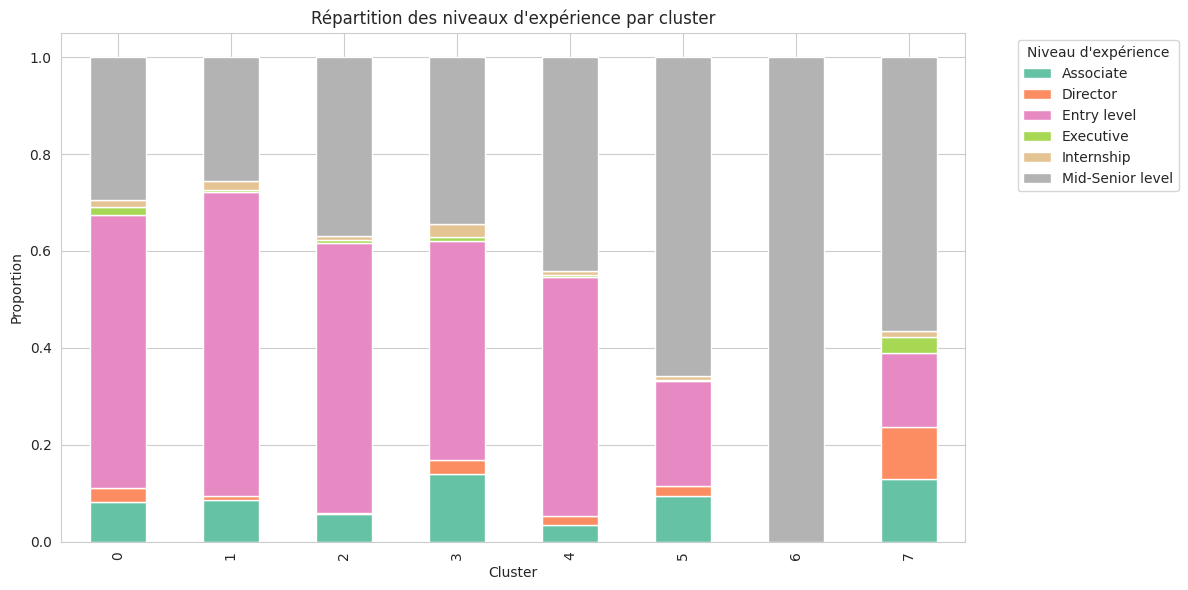


Si certains clusters concentrent des niveaux d'expérience spécifiques,
cela confirme que le clustering textuel capture implicitement des
différences de séniorité à travers le vocabulaire des descriptions.


In [26]:
if df['formatted_experience_level'].notna().sum() > 100:
    ct = pd.crosstab(df['cluster'], df['formatted_experience_level'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0)

    ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                colormap='Set2', edgecolor='white')
    plt.title("Répartition des niveaux d'expérience par cluster")
    plt.xlabel('Cluster')
    plt.ylabel('Proportion')
    plt.legend(title="Niveau d'expérience", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig('../outputs/experience_par_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nSi certains clusters concentrent des niveaux d'expérience spécifiques,")
    print("cela confirme que le clustering textuel capture implicitement des")
    print("différences de séniorité à travers le vocabulaire des descriptions.")
else:
    print("Données insuffisantes pour l'analyse croisée.")

### 6.8 Validation externe par les métadonnées du dataset

Le dataset LinkedIn contient des fichiers secondaires qui associent chaque offre à des secteurs d'activité (`job_industries.csv`) et à des catégories de compétences (`job_skills.csv`). Ces étiquettes n'ont pas été utilisées pour le clustering, mais elles constituent une source de validation externe pertinente : si les clusters textuels correspondent aux secteurs et compétences métier, cela confirme que le regroupement non supervisé a retrouvé une structure cohérente à partir du texte seul.

Les fichiers secondaires couvrent environ 98% des offres du dataset, ce qui garantit une validation fiable.

In [27]:
# Chargement des métadonnées sectorielles
df_job_ind = pd.read_csv('../Données/jobs/job_industries.csv')
df_industries = pd.read_csv('../Données/mappings/industries.csv')

# Jointure : job_id -> industry_id -> industry_name
df_job_ind = df_job_ind.merge(df_industries, on='industry_id', how='left')

# Pour chaque offre, on retient le premier secteur (le principal)
df_job_ind_first = df_job_ind.drop_duplicates(subset='job_id', keep='first')

# Fusion avec notre échantillon
df = df.merge(df_job_ind_first[['job_id', 'industry_name']], on='job_id', how='left')
coverage_ind = df['industry_name'].notna().mean()
print(f"Couverture des secteurs d'activité : {coverage_ind:.1%}")
print(f"Secteurs uniques dans l'échantillon : {df['industry_name'].nunique()}")

Couverture des secteurs d'activité : 98.9%
Secteurs uniques dans l'échantillon : 308


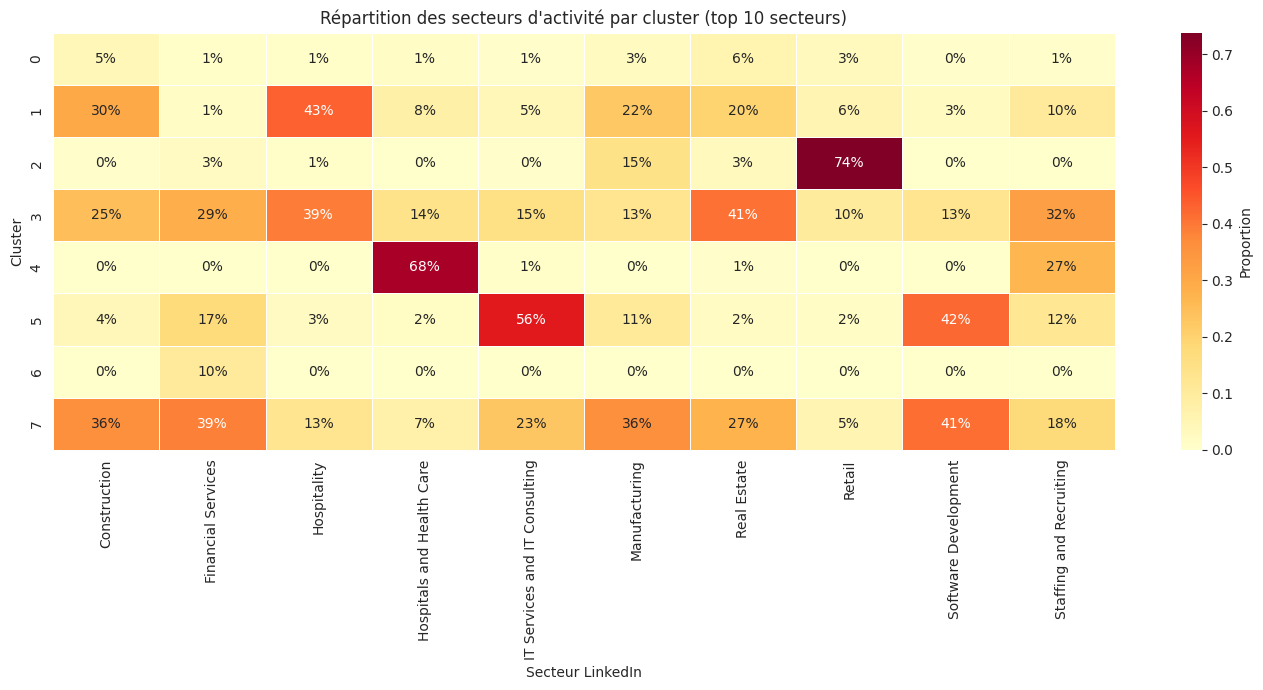


Chaque colonne montre comment un secteur LinkedIn se distribue entre les clusters.
Un secteur concentré dans un seul cluster confirme la cohérence du clustering textuel.


In [28]:
# Top 10 des secteurs les plus fréquents dans l'échantillon
top_industries = df['industry_name'].value_counts().head(10).index
df_ind_top = df[df['industry_name'].isin(top_industries)]

ct_ind = pd.crosstab(df_ind_top['cluster'], df_ind_top['industry_name'])
ct_ind_pct = ct_ind.div(ct_ind.sum(axis=0), axis=1)  # normalisation par secteur

plt.figure(figsize=(14, 7))
sns.heatmap(ct_ind_pct, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
plt.title("Répartition des secteurs d'activité par cluster (top 10 secteurs)")
plt.xlabel('Secteur LinkedIn')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/industries_par_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChaque colonne montre comment un secteur LinkedIn se distribue entre les clusters.")
print("Un secteur concentré dans un seul cluster confirme la cohérence du clustering textuel.")

In [29]:
# Chargement des métadonnées de compétences
df_job_skills = pd.read_csv('../Données/jobs/job_skills.csv')
df_skills = pd.read_csv('../Données/mappings/skills.csv')

# Jointure : skill_abr -> skill_name
df_job_skills = df_job_skills.merge(df_skills, on='skill_abr', how='left')

# On retient le premier skill par offre (le principal)
df_job_skills_first = df_job_skills.drop_duplicates(subset='job_id', keep='first')

# Fusion avec notre échantillon
df = df.merge(df_job_skills_first[['job_id', 'skill_name']], on='job_id', how='left')
coverage_sk = df['skill_name'].notna().mean()
print(f"Couverture des compétences : {coverage_sk:.1%}")
print(f"Catégories de compétences dans l'échantillon : {df['skill_name'].nunique()}")

Couverture des compétences : 98.6%
Catégories de compétences dans l'échantillon : 35


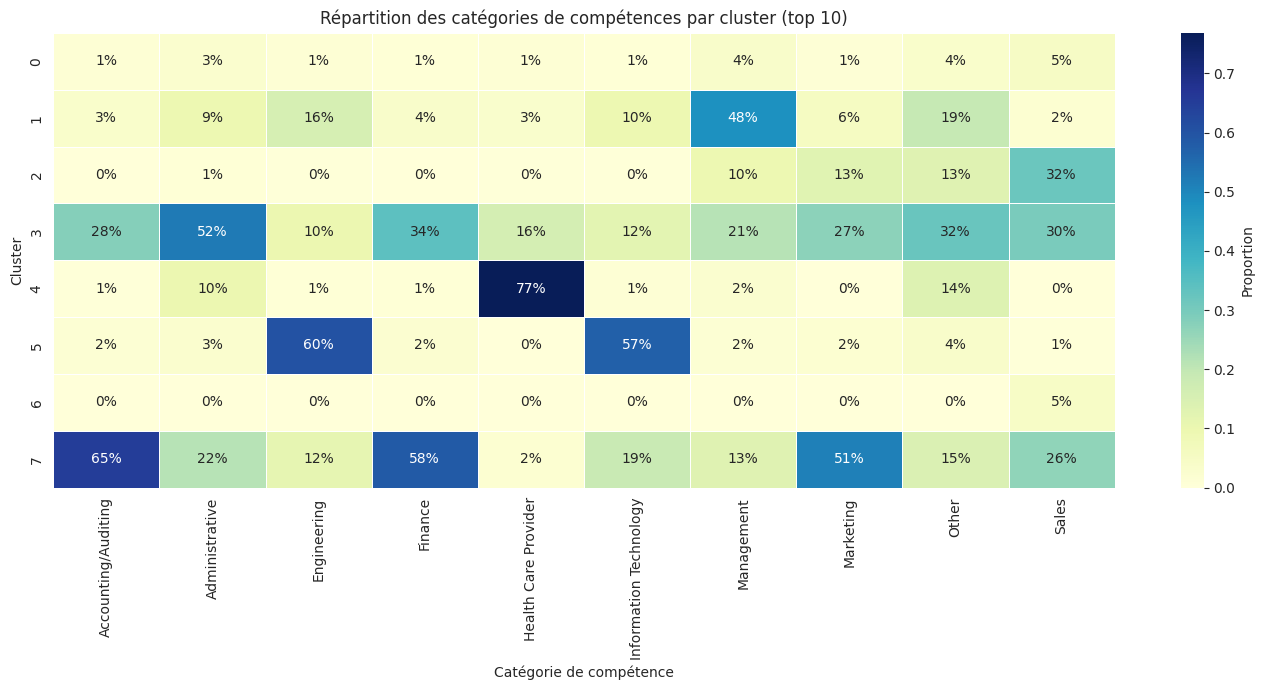


La concentration de certaines compétences dans des clusters spécifiques
confirme que le clustering textuel retrouve des distinctions métier cohérentes.


In [30]:
# Top 10 des compétences les plus fréquentes
top_skills = df['skill_name'].value_counts().head(10).index
df_sk_top = df[df['skill_name'].isin(top_skills)]

ct_sk = pd.crosstab(df_sk_top['cluster'], df_sk_top['skill_name'])
ct_sk_pct = ct_sk.div(ct_sk.sum(axis=0), axis=1)  # normalisation par compétence

plt.figure(figsize=(14, 7))
sns.heatmap(ct_sk_pct, annot=True, fmt='.0%', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
plt.title('Répartition des catégories de compétences par cluster (top 10)')
plt.xlabel('Catégorie de compétence')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/skills_par_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLa concentration de certaines compétences dans des clusters spécifiques")
print("confirme que le clustering textuel retrouve des distinctions métier cohérentes.")

### Bilan de la validation externe

Le croisement des clusters textuels avec les métadonnées structurées du dataset (secteurs d'activité LinkedIn et catégories de compétences) apporte une validation complémentaire au clustering. Si certains secteurs ou compétences se concentrent dans des clusters spécifiques, cela confirme que le regroupement non supervisé par TF-IDF et K-Means a réussi à retrouver, à partir du texte seul, une structure qui correspond aux catégories métier réelles.

Cette validation externe est particulièrement utile dans un contexte où le score silhouette est faible : elle fournit un critère d'évaluation indépendant et plus interprétable que les métriques internes.

---
## Synthèse et conclusion

### Résumé du pipeline

| Étape | Méthode | Résultat clé |
|-------|---------|------|
| Données | Échantillon de 30 000 offres LinkedIn | Corpus riche, descriptions de ~3 400 caractères en médiane |
| Prétraitement | HTML + boilerplate + stopwords + lemmatisation | ~300 tokens/document après nettoyage |
| Vectorisation | TF-IDF (10 000 features, unigrammes + bigrammes) | Matrice creuse de haute dimension |
| Clustering | K-Means (k=8) | 8 groupes thématiques identifiables |
| Comparaison | DBSCAN testé sur données réduites (50 dim.) | Non retenu : inadapté aux données textuelles |
| Évaluation | Silhouette + analyse qualitative + croisement métadonnées | Score silhouette faible mais clusters confirmés par validation externe |

### Fichiers du dataset exploités

| Fichier | Rôle |
|---------|------|
| `postings.csv` | Source principale (titre + description pour le clustering) |
| `job_industries.csv` + `industries.csv` | Validation externe par les secteurs d'activité |
| `job_skills.csv` + `skills.csv` | Validation externe par les catégories de compétences |

Les fichiers relatifs aux entreprises (`companies.csv`, `company_industries.csv`, `company_specialities.csv`, `employee_counts.csv`), aux salaires (`salaries.csv`) et aux avantages (`benefits.csv`) n'ont pas été retenus car ils ne contribuent pas directement au clustering textuel des offres d'emploi ou présentent une couverture insuffisante (< 30%).

### Limites

1. **TF-IDF** ne capture pas la sémantique (synonymie, polysémie). Deux offres décrivant le même poste avec un vocabulaire différent seront jugées dissimilaires.
2. **K-Means** impose des clusters sphériques dans l'espace TF-IDF, ce qui ne correspond pas nécessairement à la structure réelle des données.
3. **Le score silhouette** est structurellement faible en haute dimension et ne suffit pas à évaluer la qualité du clustering textuel.
4. **L'échantillonnage** (30 000 / 124 000) peut ne pas capturer certaines niches professionnelles rares.

### Pistes d'amélioration

- Tester des représentations vectorielles denses (Word2Vec, Sentence-BERT) pour mieux capturer la sémantique.
- Appliquer une réduction de dimensionnalité (TruncatedSVD à 100-200 composantes) avant K-Means.
- Explorer le clustering hiérarchique pour analyser la structure à plusieurs granularités.